<a href="https://colab.research.google.com/github/Kongbeng-21/SuperAi/blob/main/Week1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Storytelling: การเดินทางด้วยระบบขนส่งสาธารณะในไทย

ชุดข้อมูล: `passengers68.csv` (ปี 2568) และ `passengers69.csv` (ปี 2569 มกราคม)  
ที่มา: กระทรวงคมนาคม — datagov.mot.go.th

## Setup


In [1]:
!apt-get install -y fonts-tlwg-sarabun -qq
!fc-cache -fv -q

import matplotlib, shutil, os
shutil.rmtree(matplotlib.get_cachedir(), ignore_errors=True)
os.makedirs(matplotlib.get_cachedir(), exist_ok=True)
print('done')

E: Unable to locate package fonts-tlwg-sarabun
fc-cache: invalid option -- 'q'
usage: fc-cache [-EfrsvVh] [-y SYSROOT] [--error-on-no-fonts] [--force|--really-force] [--sysroot=SYSROOT] [--system-only] [--verbose] [--version] [--help] [dirs]
Build font information caches in [dirs]
(all directories in font configuration by default).

  -E, --error-on-no-fonts  raise an error if no fonts in a directory
  -f, --force              scan directories with apparently valid caches
  -r, --really-force       erase all existing caches, then rescan
  -s, --system-only        scan system-wide directories only
  -y, --sysroot=SYSROOT    prepend SYSROOT to all paths for scanning
  -v, --verbose            display status information while busy
  -V, --version            display font config version and exit
  -h, --help               display this help and exit
done


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

In [3]:
df68 = pd.read_csv('passengers68.csv', encoding='utf-8-sig', low_memory=False)
df69 = pd.read_csv('passengers69.csv', encoding='utf-8-sig', low_memory=False)

print('passengers68.csv:', df68.shape)
print('passengers69.csv:', df69.shape)
df68.head()

passengers68.csv: (69440, 8)
passengers69.csv: (3010, 8)


,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
0,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,บขส.,รถ บขส. และ รถร่วม,01/01/2025,คน,"127,551"
1,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,ขบ.,รถหมวด 3,01/01/2025,คน,"8,218"
2,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ),01/01/2025,คัน,"877,943"
3,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์ทุกประเภท (10 จุดสำรวจ),01/01/2025,คัน,"932,642"
4,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,กทพ.,รถยนต์เฉพาะ 4 ล้อ (ทางด่วน),01/01/2025,คัน,"1,364,992"


## Data Preparation

### 1.ทำความเข้าใจโครงสร้างข้อมูล

In [4]:
# Column structure
print(df68.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69440 entries, 0 to 69439
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   รูปแบบการเดินทาง   15696 non-null  object
 1   วัตถุประสงค์       15696 non-null  object
 2   สาธารณะ/ส่วนบุคคล  15696 non-null  object
 3   หน่วยงาน           15696 non-null  object
 4   ยานพาหนะ/ท่า       15696 non-null  object
 5   วันที่             15696 non-null  object
 6   หน่วย              15696 non-null  object
 7   ปริมาณ             15388 non-null  object
dtypes: object(8)
memory usage: 4.2+ MB
None


In [5]:
# Basic stat
df68.describe()

,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
count,15696,15696,15696,15696,15696,15696,15696,15388
unique,4,3,2,13,43,365,2,12162
top,ทางอากาศ,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,ทอท.,ท่าอากาศยานภูมิภาค ขาออกประเทศ,21/10/2025,คน,0
freq,5111,5840,14236,3285,366,44,14236,583


In [6]:
# Unique values in categorical columns
for col in ['รูปแบบการเดินทาง', 'วัตถุประสงค์', 'สาธารณะ/ส่วนบุคคล']:
    print(f'{col}:', df68[col].unique())

รูปแบบการเดินทาง: ['ทางถนน' 'ทางน้ำ' 'ทางราง' 'ทางอากาศ' nan]
วัตถุประสงค์: ['การเดินทางระหว่างจังหวัด' 'การเดินทางภายในจังหวัด/กรุงเทพ'
 'การเดินทางระหว่างประเทศ' nan]
สาธารณะ/ส่วนบุคคล: ['สาธารณะ' 'ส่วนบุคคล' nan]


In [7]:
# All vehicle types
print(df68['ยานพาหนะ/ท่า'].unique())

['รถ บขส. และ รถร่วม' 'รถหมวด 3' 'รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ)'
 'รถยนต์ทุกประเภท (10 จุดสำรวจ)' 'รถยนต์เฉพาะ 4 ล้อ (ทางด่วน)'
 'รถยนต์ทุกประเภท (ทางด่วน)' 'รถหมวด 4' 'รถเมล์ ขสมก.' 'รถร่วม (หมวด 1)'
 'รถเอกชนเส้นปฏิรูป (หมวด 1)' 'เรือด่วนเจ้าพระยา' 'เรือคลองแสนแสบ'
 'เรือข้ามฟากเจ้าพระยา' 'เรือไฟฟ้าเจ้าพระยา' 'เรือภูมิภาค' 'รถไฟ'
 'รถไฟฟ้าสายสีน้ำเงิน' 'รถไฟฟ้าสายสีม่วง' 'รถไฟฟ้าสายสีเหลือง'
 'รถไฟฟ้าสายสีชมพู' 'รถไฟฟ้า ARL' 'รถไฟฟ้า BTS' 'รถไฟฟ้าสายสีแดง'
 'ท่าอากาศยานสุวรรณภูมิ' 'ท่าอากาศยานดอนเมือง' 'ท่าอากาศอื่น ๆ ของ ทอท.'
 'ท่าอากาศยานภูมิภาค' 'ท่าอากาศยานอู่ตะเภา' 'ท่าอากาศยานสมุย'
 'รถ บขส. ขาเข้าประเทศ' 'รถ บขส. ขาออกประเทศ' 'รถไฟ ขาเข้าประเทศ'
 'รถไฟ ขาออกประเทศ' 'ท่าเรือด่านชายแดน ขาเข้าประเทศ'
 'ท่าเรือด่านชายแดน ขาออกประเทศ' 'ท่าอากาศยานสุวรรณภูมิ ขาเข้าประเทศ'
 'ท่าอากาศยานสุวรรณภูมิ ขาออกประเทศ' 'ท่าอากาศยานดอนเมือง ขาเข้าประเทศ'
 'ท่าอากาศยานดอนเมือง ขาออกประเทศ'
 'ท่าอากาศยานอื่น ๆ ของ ทอท. ขาเข้าประเทศ'
 'ท่าอากาศยานอื่น ๆ ของ ทอท. ขาออกประเทศ'
 'ท่าอากาศยานภูมิภา

### ทำความสะอาดข้อมูล (Data Cleaning)

In [8]:
# Check null values
print('Null — passengers68.csv')
print(df68.isnull().sum())
print()
print('Null — passengers69.csv')
print(df69.isnull().sum())

Null — passengers68.csv
รูปแบบการเดินทาง     53744
วัตถุประสงค์         53744
สาธารณะ/ส่วนบุคคล    53744
หน่วยงาน             53744
ยานพาหนะ/ท่า         53744
วันที่               53744
หน่วย                53744
ปริมาณ               54052
dtype: int64

Null — passengers69.csv
รูปแบบการเดินทาง       0
วัตถุประสงค์           0
สาธารณะ/ส่วนบุคคล      0
หน่วยงาน               0
ยานพาหนะ/ท่า           0
วันที่                 0
หน่วย                  0
ปริมาณ               136
dtype: int64


In [9]:
# Check duplicates
dup68 = df68.duplicated().sum()
dup69 = df69.duplicated().sum()
print(f'Duplicates 68: {dup68:,} rows ({dup68/len(df68)*100:.1f}%)')
print(f'Duplicates 69: {dup69:,} rows')

Duplicates 68: 53,744 rows (77.4%)
Duplicates 69: 0 rows


In [10]:
# Check data types
print(df68.dtypes)
print()
print('Sample ปริมาณ:', df68['ปริมาณ'].head(3).tolist())

รูปแบบการเดินทาง     object
วัตถุประสงค์         object
สาธารณะ/ส่วนบุคคล    object
หน่วยงาน             object
ยานพาหนะ/ท่า         object
วันที่               object
หน่วย                object
ปริมาณ               object
dtype: object

Sample ปริมาณ: ['127,551', '8,218', '877,943']


In [11]:
# Cleaning Log — สรุปปัญหาที่พบก่อนclean

dup68  = df68.duplicated().sum()
null68 = df68.isnull().sum().sum()
dup69  = df69.duplicated().sum()
null69 = df69['ปริมาณ'].isnull().sum()

print('Issue                              | File              | Rows affected')
print('-' * 70)
print(f'Duplicate rows                     | passengers68.csv  | {dup68:,} ({dup68/len(df68)*100:.0f}%)')
print(f'ปริมาณ stored as string with comma | Both files        | All rows')
print(f'วันที่ stored as string            | Both files        | All rows')
print(f'Null in ปริมาณ                     | passengers69.csv  | {null69} rows')

Issue                              | File              | Rows affected
----------------------------------------------------------------------
Duplicate rows                     | passengers68.csv  | 53,744 (77%)
ปริมาณ stored as string with comma | Both files        | All rows
วันที่ stored as string            | Both files        | All rows
Null in ปริมาณ                     | passengers69.csv  | 136 rows


### จัดรูปแบบข้อมูลให้พร้อมสำหรับการวิเคราะห์

In [12]:
def clean_df(df, label):
    print(f'--- {label} ---')
    print(f'Before: {df.shape[0]:,} rows')

    # Remove duplicates
    df = df.drop_duplicates()
    print(f'After dedup: {df.shape[0]:,} rows')

    # Convert ปริมาณ to numeric
    df['ปริมาณ'] = df['ปริมาณ'].astype(str).str.replace(',', '').str.strip()
    df['ปริมาณ'] = pd.to_numeric(df['ปริมาณ'], errors='coerce')

    # Convert วันที่ to datetime
    df['วันที่'] = pd.to_datetime(df['วันที่'], format='%d/%m/%Y', errors='coerce')

    # Drop null
    n_null = df['ปริมาณ'].isnull().sum()
    df = df.dropna(subset=['ปริมาณ'])
    print(f'Dropped null ปริมาณ: {n_null} rows')

    # Add helper columns
    df['year']       = df['วันที่'].dt.year
    df['month']      = df['วันที่'].dt.month
    df['dayofweek']  = df['วันที่'].dt.dayofweek  # 0=Mon, 6=Sun
    df['is_weekend'] = df['dayofweek'] >= 5

    print(f'After clean: {df.shape[0]:,} rows')
    print()
    return df.reset_index(drop=True)

df68 = clean_df(df68, 'passengers68.csv')
df69 = clean_df(df69, 'passengers69.csv')

df_all = pd.concat([df68, df69], ignore_index=True)
print(f'Total: {df_all.shape[0]:,} rows')

--- passengers68.csv ---
Before: 69,440 rows
After dedup: 15,696 rows
Dropped null ปริมาณ: 309 rows
After clean: 15,387 rows

--- passengers69.csv ---
Before: 3,010 rows
After dedup: 3,010 rows
Dropped null ปริมาณ: 136 rows
After clean: 2,874 rows

Total: 18,261 rows


In [13]:
print('Date range 68:', df68['วันที่'].min().date(), 'to', df68['วันที่'].max().date())
print('Date range 69:', df69['วันที่'].min().date(), 'to', df69['วันที่'].max().date())
print('Vehicle types:', df_all['ยานพาหนะ/ท่า'].nunique())
df68.head()

Date range 68: 2025-01-01 to 2025-12-31
Date range 69: 2026-01-01 to 2026-03-11
Vehicle types: 43


,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ,year,month,dayofweek,is_weekend
0,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,บขส.,รถ บขส. และ รถร่วม,2025-01-01,คน,127551.0,2025,1,2,False
1,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,ขบ.,รถหมวด 3,2025-01-01,คน,8218.0,2025,1,2,False
2,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ),2025-01-01,คัน,877943.0,2025,1,2,False
3,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์ทุกประเภท (10 จุดสำรวจ),2025-01-01,คัน,932642.0,2025,1,2,False
4,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,กทพ.,รถยนต์เฉพาะ 4 ล้อ (ทางด่วน),2025-01-01,คัน,1364992.0,2025,1,2,False


## Exploratory Data Analysis (EDA)

### สำรวจลักษณะของข้อมูล

In [14]:
rail_vehicles = [
    'รถไฟฟ้า BTS', 'รถไฟฟ้าสายสีน้ำเงิน', 'รถไฟฟ้าสายสีม่วง',
    'รถไฟฟ้าสายสีเหลือง', 'รถไฟฟ้าสายสีชมพู', 'รถไฟฟ้า ARL', 'รถไฟฟ้าสายสีแดง'
]
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2']

# แปลงชื่อเป็นอังกฤษไว้ใช้ตอนplot
line_name_en = {
    'รถไฟฟ้า BTS':        'BTS Skytrain',
    'รถไฟฟ้าสายสีน้ำเงิน': 'MRT Blue Line',
    'รถไฟฟ้าสายสีม่วง':   'MRT Purple Line',
    'รถไฟฟ้าสายสีเหลือง': 'MRT Yellow Line',
    'รถไฟฟ้าสายสีชมพู':   'MRT Pink Line',
    'รถไฟฟ้า ARL':        'Airport Rail Link',
    'รถไฟฟ้าสายสีแดง':    'Red Line (Suburban)'
}
color_map = {
    'BTS Skytrain':       '#ff7f0e',  # orange
    'MRT Blue Line':      '#1f77b4',  # blue
    'MRT Purple Line':    '#9467bd',  # purple
    'MRT Yellow Line':    '#f0c30f',  # yellow
    'MRT Pink Line':      '#e377c2',  # pink
    'Airport Rail Link':  '#2ca02c',  # green
    'Red Line (Suburban)':'#d62728',  # red
}
rail68 = df68[df68['ยานพาหนะ/ท่า'].isin(rail_vehicles)].copy()
rail68['line_en'] = rail68['ยานพาหนะ/ท่า'].map(line_name_en)

# KPI รวมทั้งปี
total      = rail68['ปริมาณ'].sum()
avg_day    = rail68.groupby('วันที่')['ปริมาณ'].sum().mean()
top_line   = rail68.groupby('ยานพาหนะ/ท่า')['ปริมาณ'].sum().idxmax()

print(f'Total passengers 2568 : {total:,.0f}')
print(f'Average per day       : {avg_day:,.0f}')
print(f'Busiest line          : {top_line}')

Total passengers 2568 : 519,066,259
Average per day       : 1,422,099
Busiest line          : รถไฟฟ้า BTS


In [15]:
# สถิติแยกตามสาย
stats = rail68.groupby('line_en')['ปริมาณ'].agg(['mean','median','std','min','max'])
stats.columns = ['mean/day', 'median', 'std', 'min', 'max']
stats = stats.sort_values('mean/day', ascending=False)
display(stats.style.format('{:,.0f}'))

,mean/day,median,std,min,max
line_en,,,,,
BTS Skytrain,"723,268","787,360","149,004","334,446","1,206,443"
MRT Blue Line,"424,484","470,108","100,941","198,521","712,781"
MRT Purple Line,"67,956","78,479","19,630","29,802","110,632"
Airport Rail Link,"64,847","68,911","13,401",0,"101,641"
MRT Pink Line,"61,618","66,052","16,839",0,"131,854"
MRT Yellow Line,"45,326","47,672","10,146",0,"96,432"
Red Line (Suburban),"36,243","38,688","7,477","19,682","61,216"


### Distribution ผู้โดยสารรายวัน

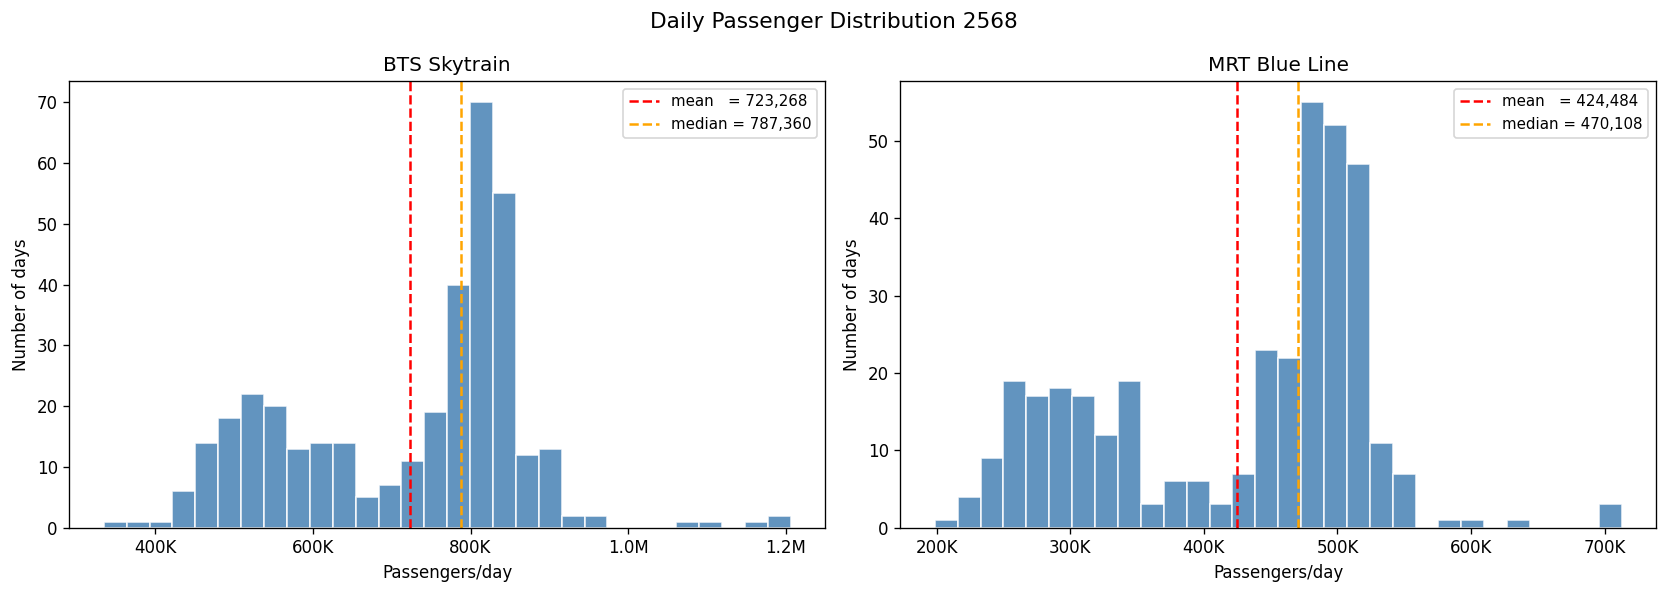

In [16]:
# histogramของ2สายหลัก ดูการกระจายตัวและoutlier
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, vehicle in zip(axes, ['BTS Skytrain', 'MRT Blue Line']):
    data = rail68[rail68['line_en'] == vehicle]['ปริมาณ']
    ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='red',    linestyle='--', label=f'mean   = {data.mean():,.0f}')
    ax.axvline(data.median(), color='orange', linestyle='--', label=f'median = {data.median():,.0f}')
    ax.set_title(vehicle)
    ax.set_xlabel('Passengers/day')
    ax.set_ylabel('Number of days')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))

fig.suptitle('Daily Passenger Distribution 2568', fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
print('Observations from Distribution:')
print()
for vehicle in rail68['line_en'].unique():
    data = rail68[rail68['line_en'] == vehicle]['ปริมาณ']
    skew = data.skew()
    direction = 'left-skewed (มีวันผู้โดยสารน้อยผิดปกติ)' if skew < -0.5 else \
                'right-skewed (มีวันผู้โดยสารสูงผิดปกติ)' if skew > 0.5 else 'roughly normal'
    print(f'{vehicle}: skew = {skew:.2f} -> {direction}')

Observations from Distribution:

MRT Blue Line: skew = -0.43 -> roughly normal
MRT Purple Line: skew = -0.53 -> left-skewed (มีวันผู้โดยสารน้อยผิดปกติ)
MRT Yellow Line: skew = 0.24 -> roughly normal
MRT Pink Line: skew = -0.21 -> roughly normal
Airport Rail Link: skew = -1.29 -> left-skewed (มีวันผู้โดยสารน้อยผิดปกติ)
BTS Skytrain: skew = -0.29 -> roughly normal
Red Line (Suburban): skew = -0.28 -> roughly normal


### Monthly Trend

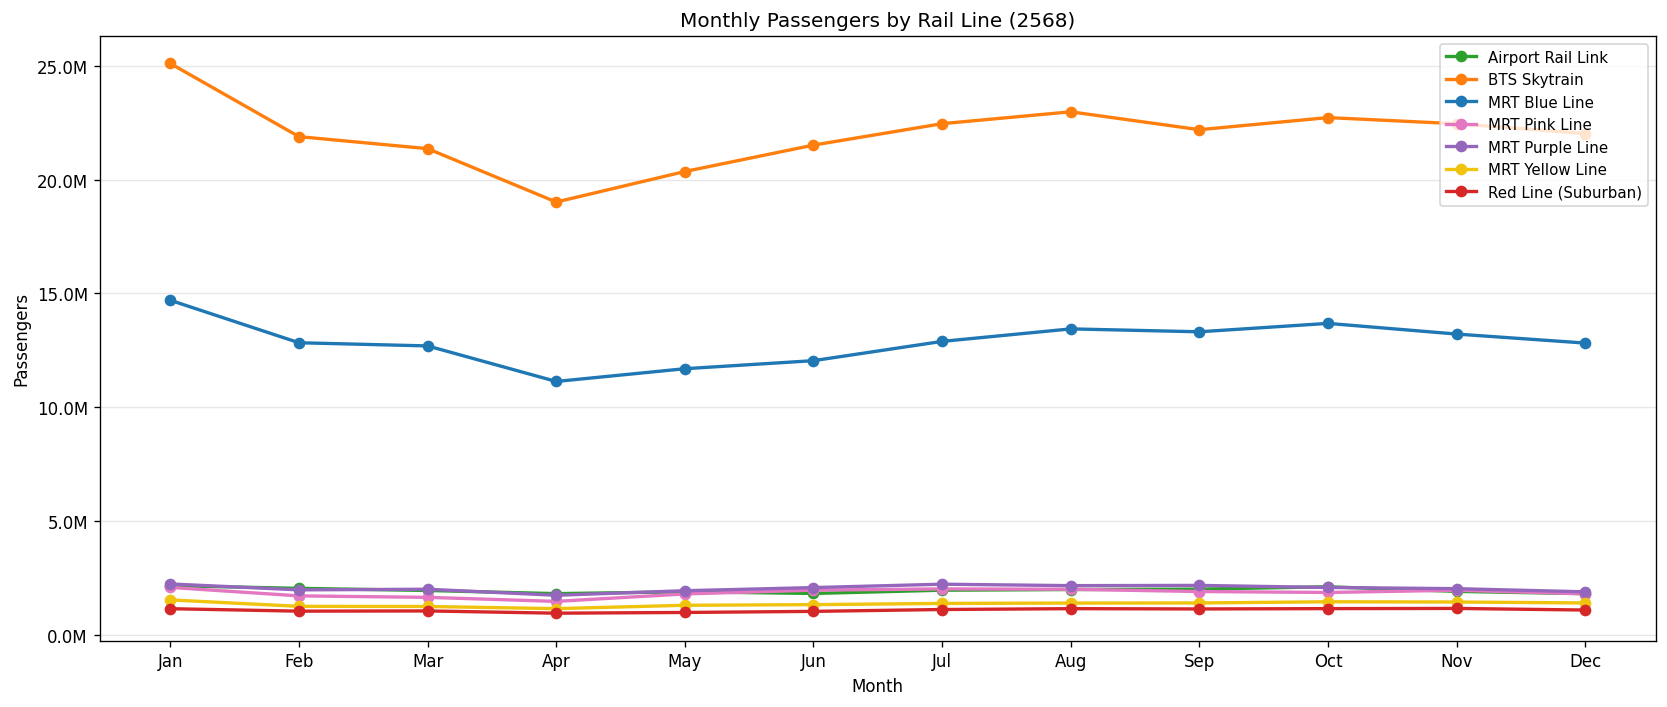

In [18]:
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

monthly = rail68.groupby(['month', 'line_en'])['ปริมาณ'].sum().reset_index()
pivot = monthly.pivot(index='month', columns='line_en', values='ปริมาณ')

fig, ax = plt.subplots(figsize=(14, 6))
for i, col in enumerate(pivot.columns):
    ax.plot(list(month_names.values()), pivot[col].values,
            marker='o', label=col, color=color_map.get(col, 'gray'), linewidth=2)

ax.set_title('Monthly Passengers by Rail Line (2568)')
ax.set_xlabel('Month')
ax.set_ylabel('Passengers')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('eda_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### Weekday vs Weekend

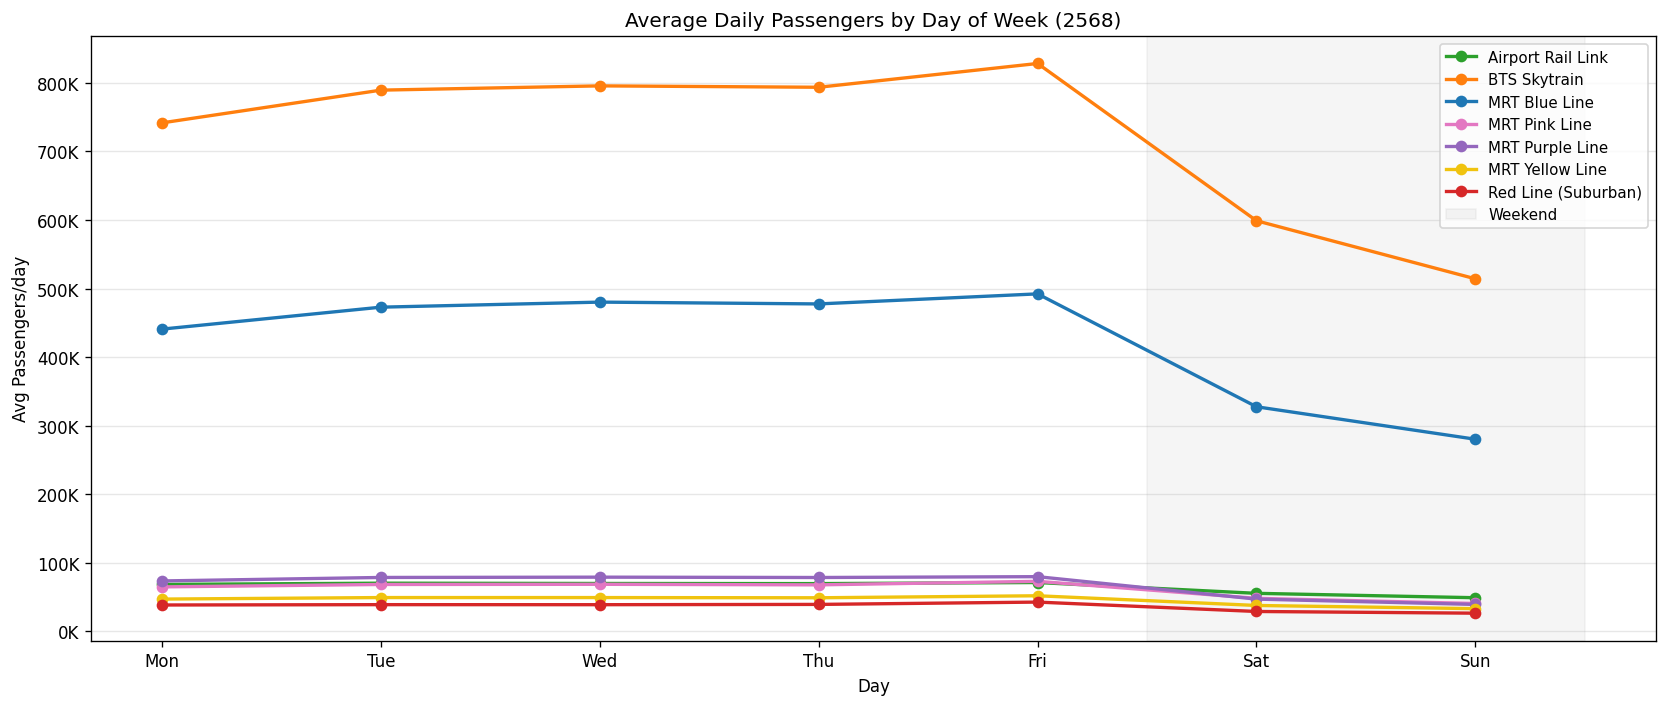

In [19]:
# ดูว่าคนใช้รถไฟฟ้าไปทำงานหรือเที่ยว
day_labels = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}

daily_by_dow = rail68.groupby(['dayofweek', 'line_en'])['ปริมาณ'].mean().reset_index()
pivot_dow = daily_by_dow.pivot(index='dayofweek', columns='line_en', values='ปริมาณ')

fig, ax = plt.subplots(figsize=(14, 6))
for i, col in enumerate(pivot_dow.columns):
    ax.plot(list(day_labels.values()), pivot_dow[col].values,
            marker='o', label=col, color=color_map.get(col, 'gray'), linewidth=2)

ax.axvspan(4.5, 6.5, alpha=0.08, color='gray', label='Weekend')
ax.set_title('Average Daily Passengers by Day of Week (2568)')
ax.set_xlabel('Day')
ax.set_ylabel('Avg Passengers/day')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('eda_dow.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# คำนวณ % drop วันหยุด
print('Weekday vs Weekend drop:')
print()
for line in rail68['line_en'].unique():
    data = rail68[rail68['line_en'] == line]
    wd = data[~data['is_weekend']]['ปริมาณ'].mean()
    we = data[data['is_weekend']]['ปริมาณ'].mean()
    drop = (wd - we) / wd * 100
    print(f'{line}: weekday avg = {wd:,.0f} | weekend avg = {we:,.0f} | drop = {drop:.1f}%')

Weekday vs Weekend drop:

MRT Blue Line: weekday avg = 472,724 | weekend avg = 303,882 | drop = 35.7%
MRT Purple Line: weekday avg = 77,888 | weekend avg = 43,125 | drop = 44.6%
MRT Yellow Line: weekday avg = 49,290 | weekend avg = 35,417 | drop = 28.1%
MRT Pink Line: weekday avg = 68,509 | weekend avg = 44,392 | drop = 35.2%
Airport Rail Link: weekday avg = 69,869 | weekend avg = 52,244 | drop = 25.2%
BTS Skytrain: weekday avg = 789,712 | weekend avg = 556,518 | drop = 29.5%
Red Line (Suburban): weekday avg = 39,634 | weekend avg = 27,734 | drop = 30.0%


### เชื่อมผล EDA ไปยัง Insight Discovery

In [21]:
# สรุปคำถามที่ได้จาก EDA เพื่อนำไปตอบใน Section 3
print('Questions from EDA -> Section 3:')
print()
print('Q1: BTS ครองสัดส่วนมากที่สุด -> สายอื่นมี modal share เป็นเท่าไหร่?')
print('    และเมื่อเทียบ ม.ค. 68 vs 69 แต่ละสายเติบโตหรือหดตัว?')
print()
print('Q2: แต่ละสายมี distribution และ weekday drop ต่างกัน')
print('    -> สายไหนผันผวนมากที่สุด สายไหนเสถียรที่สุด?')
print()
print('Q3: monthly trend มีบางเดือนที่ต่ำผิดปกติ')
print('    -> จุดเหล่านั้นสอดคล้องกับวันหยุดหรือเทศกาลอะไร?')

Questions from EDA -> Section 3:

Q1: BTS ครองสัดส่วนมากที่สุด -> สายอื่นมี modal share เป็นเท่าไหร่?
    และเมื่อเทียบ ม.ค. 68 vs 69 แต่ละสายเติบโตหรือหดตัว?

Q2: แต่ละสายมี distribution และ weekday drop ต่างกัน
    -> สายไหนผันผวนมากที่สุด สายไหนเสถียรที่สุด?

Q3: monthly trend มีบางเดือนที่ต่ำผิดปกติ
    -> จุดเหล่านั้นสอดคล้องกับวันหยุดหรือเทศกาลอะไร?


## Insight Discovery

### ข้อ 1: Modal Share — คนไทยเดินทางด้วยอะไรมากที่สุด?

In [22]:
modal_map = {
    'รถไฟฟ้า BTS':        'BTS Skytrain',
    'รถไฟฟ้าสายสีน้ำเงิน': 'MRT Blue Line',
    'รถไฟฟ้า ARL':        'Airport Rail Link',
    'รถไฟฟ้าสายสีแดง':    'Red Line (Suburban)'
}

# สัดส่วนทั้งปี 2568
modal68 = df68[df68['ยานพาหนะ/ท่า'].isin(modal_map)].copy()
modal68['line_en'] = modal68['ยานพาหนะ/ท่า'].map(modal_map)
share68 = modal68.groupby('line_en')['ปริมาณ'].sum()

# เปรียบเทียบ ม.ค. 68 vs ม.ค. 69
modal68_jan = modal68[modal68['month'] == 1].groupby('line_en')['ปริมาณ'].sum()
modal69 = df69[df69['ยานพาหนะ/ท่า'].isin(modal_map)].copy()
modal69['line_en'] = modal69['ยานพาหนะ/ท่า'].map(modal_map)
share69 = modal69.groupby('line_en')['ปริมาณ'].sum()

growth = ((share69 - modal68_jan) / modal68_jan * 100).round(1)
print('การเติบโต ม.ค. 2568 vs 2569 (%)')
print(growth)

การเติบโต ม.ค. 2568 vs 2569 (%)
line_en
Airport Rail Link      130.3
BTS Skytrain            99.4
MRT Blue Line          112.7
Red Line (Suburban)    125.7
Name: ปริมาณ, dtype: float64


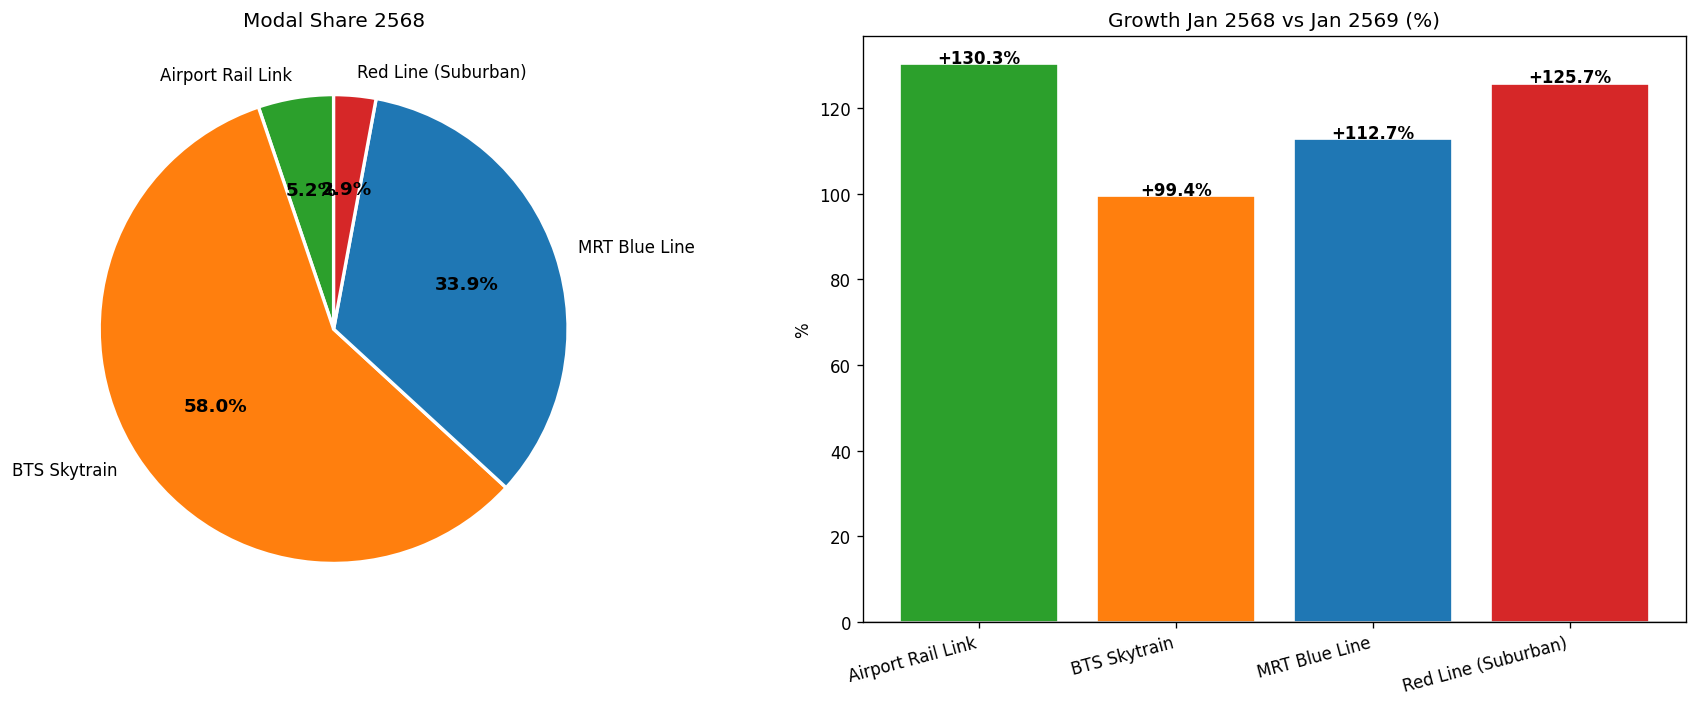

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Pie — สัดส่วนทั้งปี 2568
colors_pie = [color_map.get(label, 'gray') for label in share68.index]
wedges, texts, autotexts = axes[0].pie(
    share68.values, labels=share68.index,
    autopct='%1.1f%%', colors=colors_pie,
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
axes[0].set_title('Modal Share 2568')

# Bar — การเติบโต ม.ค. 68 vs 69
bar_c = [color_map.get(line, 'gray') for line in growth.index]
bars = axes[1].bar(growth.index, growth.values, color=bar_c, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Growth Jan 2568 vs Jan 2569 (%)')
axes[1].set_ylabel('%')
axes[1].set_xticklabels(growth.index, rotation=15, ha='right')
for bar, val in zip(bars, growth.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:+.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('q1_modal_share.png', dpi=150, bbox_inches='tight')
plt.show()

### ข้อ 2: รถไฟฟ้าในกรุงเทพฯ แต่ละสายมีพฤติกรรมผู้โดยสารต่างกันอย่างไร?
Urban Rail Comparison

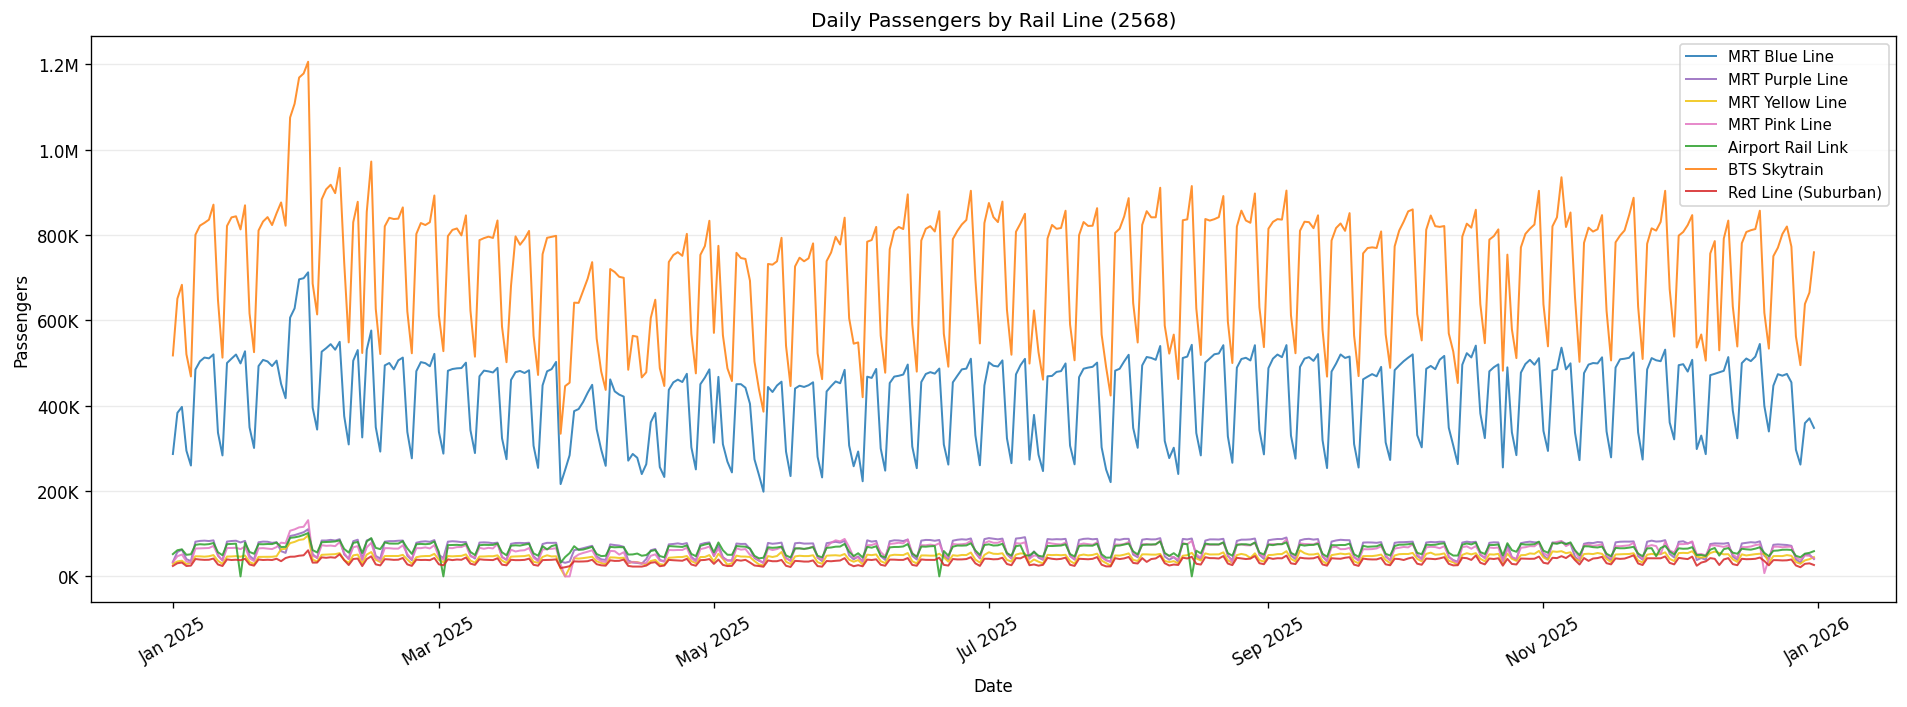

In [24]:
# Daily passengers ทุกสาย
fig, ax = plt.subplots(figsize=(16, 6))
for i, line in enumerate(rail68['line_en'].unique()):
    data = rail68[rail68['line_en'] == line].sort_values('วันที่')
    ax.plot(data['วันที่'], data['ปริมาณ'],
            label=line, color=color_map.get(line, 'gray'), linewidth=1.2, alpha=0.85)

ax.set_title('Daily Passengers by Rail Line (2568)')
ax.set_xlabel('Date')
ax.set_ylabel('Passengers')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('q2_daily.png', dpi=150, bbox_inches='tight')
plt.show()

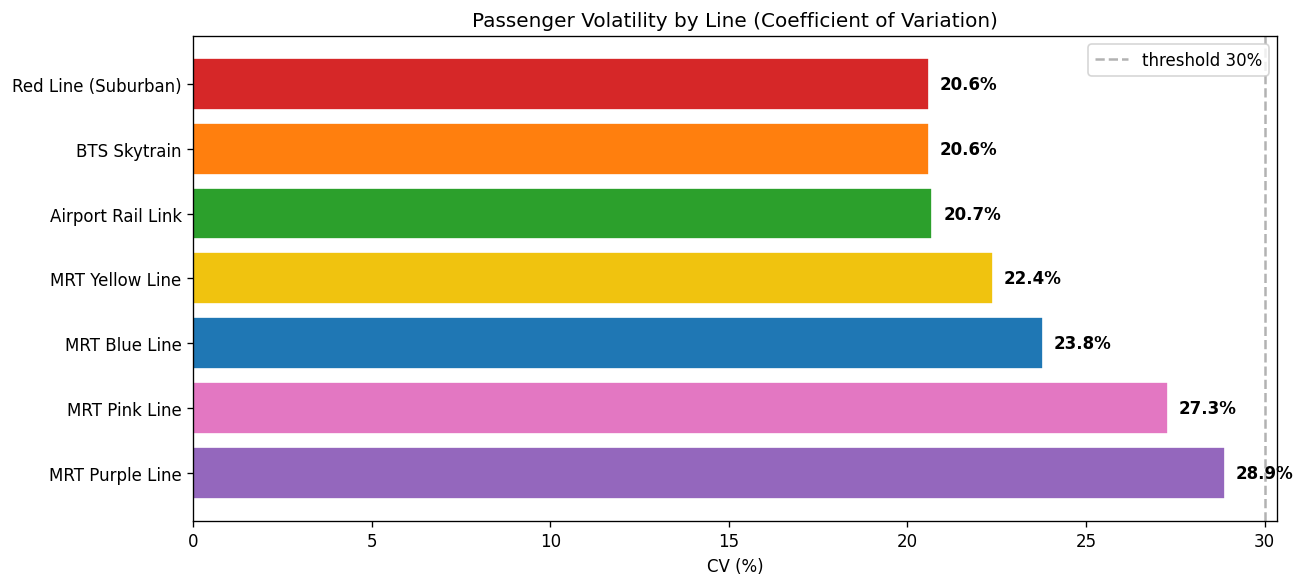

,line,mean/day,CV (%)
4,MRT Purple Line,"67,956",28.9%
3,MRT Pink Line,"61,618",27.3%
2,MRT Blue Line,"424,484",23.8%
5,MRT Yellow Line,"45,326",22.4%
0,Airport Rail Link,"64,847",20.7%
1,BTS Skytrain,"723,268",20.6%
6,Red Line (Suburban),"36,243",20.6%


In [25]:
# วัดความผันผวนด้วย Coefficient of Variation (CV = std/mean)
cv_df = rail68.groupby('line_en')['ปริมาณ'].agg(['mean', 'std']).reset_index()
cv_df['CV (%)'] = (cv_df['std'] / cv_df['mean'] * 100).round(1)
cv_df.columns = ['line', 'mean/day', 'std', 'CV (%)']
cv_df = cv_df.sort_values('CV (%)', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
bar_c = [color_map.get(line, 'gray') for line in cv_df['line']]
bars = ax.barh(cv_df['line'], cv_df['CV (%)'], color=bar_c, edgecolor='white')
ax.axvline(30, color='gray', linestyle='--', alpha=0.6, label='threshold 30%')
ax.set_title('Passenger Volatility by Line (Coefficient of Variation)')
ax.set_xlabel('CV (%)')
for bar, val in zip(bars, cv_df['CV (%)']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('q2_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

display(cv_df[['line', 'mean/day', 'CV (%)']].style.format({'mean/day': '{:,.0f}', 'CV (%)': '{:.1f}%'}))

In [26]:
# Insight ข้อ 2
most_volatile = cv_df.iloc[0]['line']
most_stable   = cv_df.iloc[-1]['line']

print(f'สายที่ผันผวนมากที่สุด: {most_volatile} (CV = {cv_df.iloc[0]["CV (%)"]:.1f}%)')
print(f'  -> ปริมาณผู้โดยสารขึ้นลงรายวันสูง อาจเชื่อมกับวันหยุดหรือนักท่องเที่ยว')
print()
print(f'สายที่เสถียรที่สุด: {most_stable} (CV = {cv_df.iloc[-1]["CV (%)"]:.1f}%)')
print(f'  -> ฐาน commuter แน่น ใช้งานสม่ำเสมอทุกวัน')

สายที่ผันผวนมากที่สุด: MRT Purple Line (CV = 28.9%)
  -> ปริมาณผู้โดยสารขึ้นลงรายวันสูง อาจเชื่อมกับวันหยุดหรือนักท่องเที่ยว

สายที่เสถียรที่สุด: Red Line (Suburban) (CV = 20.6%)
  -> ฐาน commuter แน่น ใช้งานสม่ำเสมอทุกวัน


### ข้อ 3: Event Detection — วันหยุดและเทศกาลเห็นได้ในข้อมูลไหม?

In [27]:
# กรอง df69 ให้เหลือแค่สายรถไฟฟ้าเหมือน rail68
rail69 = df69[df69['ยานพาหนะ/ท่า'].isin(rail_vehicles)].copy()
rail69['line_en'] = rail69['ยานพาหนะ/ท่า'].map(line_name_en)

# ต่อ rail68 (ม.ค.-ธ.ค. 68) กับ rail69 (ม.ค. 69) เข้าด้วยกัน
rail_all = pd.concat([rail68, rail69], ignore_index=True)

# รวมผู้โดยสารทุกสายต่อวัน
daily = rail_all.groupby('วันที่')['ปริมาณ'].sum().reset_index()
daily.columns = ['วันที่', 'total']
daily = daily.sort_values('วันที่')

# Z-score หาจุดผิดปกติ
mu    = daily['total'].mean()
sigma = daily['total'].std()
daily['z']       = (daily['total'] - mu) / sigma
daily['anomaly'] = daily['z'].abs() > 1.8

print(f'ค่าเฉลี่ย/วัน: {mu:,.0f} คน')
print(f'Std Dev:       {sigma:,.0f} คน')
print(f'วันที่ผิดปกติ: {daily["anomaly"].sum()} วัน')

ค่าเฉลี่ย/วัน: 1,425,821 คน
Std Dev:       308,451 คน
วันที่ผิดปกติ: 17 วัน


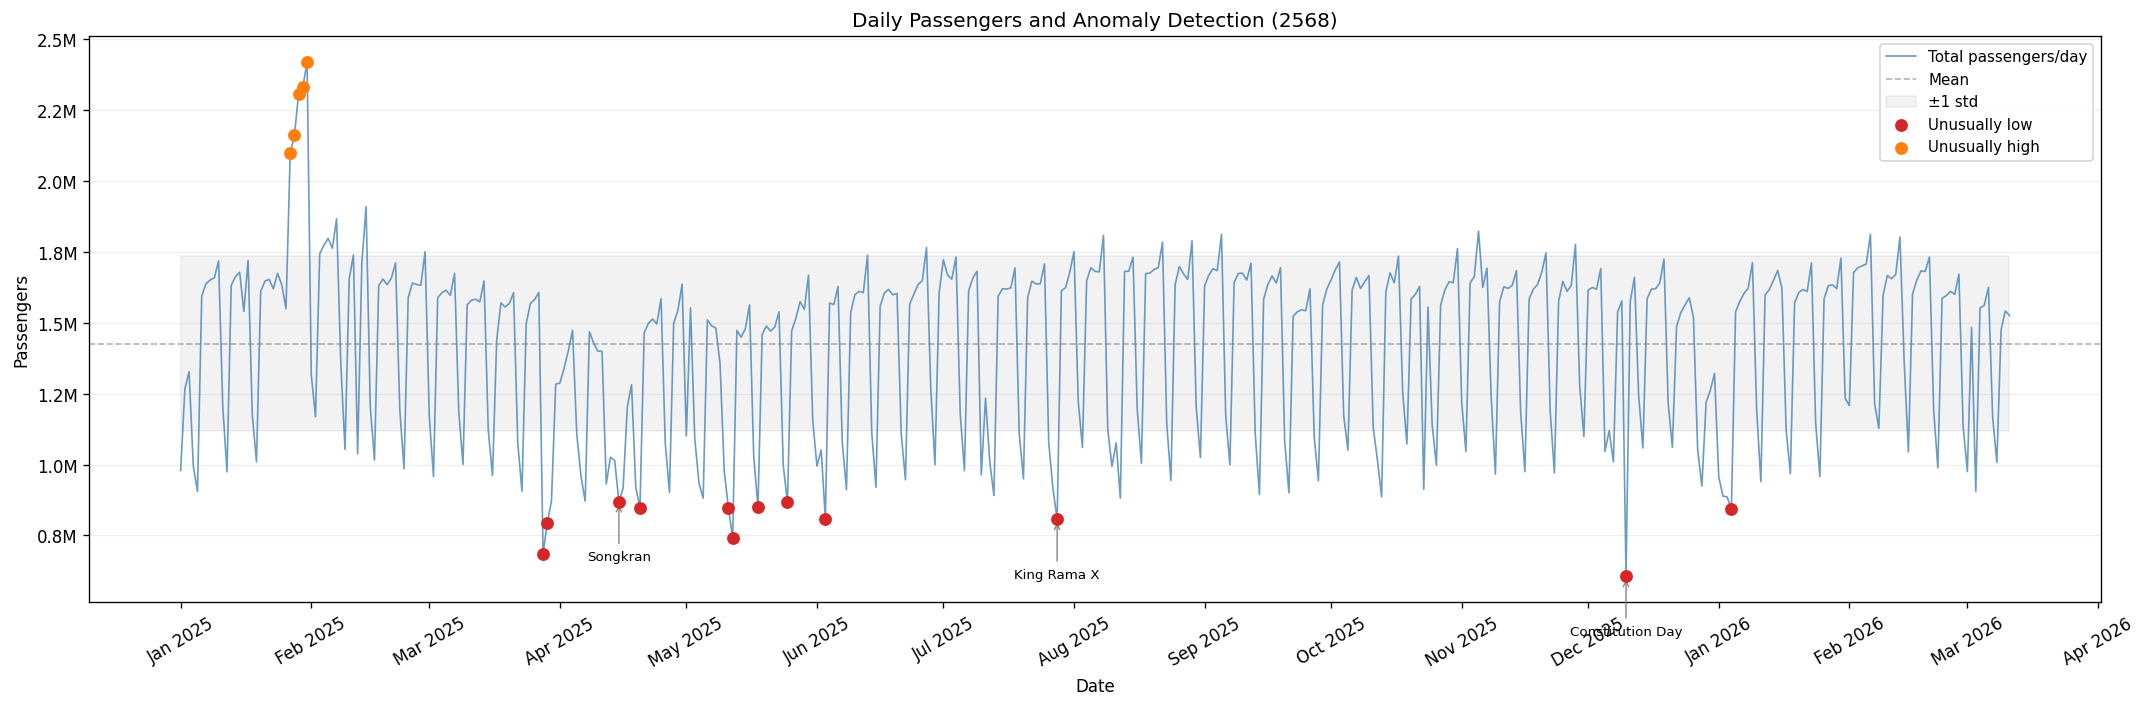

In [28]:
holidays = {
    '2025-01-01': 'New Year',
    '2025-04-06': 'Chakri Day',
    '2025-04-13': 'Songkran',
    '2025-04-14': 'Songkran',
    '2025-04-15': 'Songkran',
    '2025-05-01': 'Labour Day',
    '2025-05-05': 'Coronation Day',
    '2025-07-28': 'King Rama X',
    '2025-08-12': "Queen's Birthday",
    '2025-10-13': 'King Rama IX Memorial',
    '2025-10-23': 'Chulalongkorn Day',
    '2025-12-05': "King's Birthday",
    '2025-12-10': 'Constitution Day',
    '2025-12-31': "New Year's Eve",
}

fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(daily['วันที่'], daily['total'],
        color='steelblue', linewidth=1.0, alpha=0.8, label='Total passengers/day')
ax.axhline(mu, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Mean')
ax.fill_between(daily['วันที่'], mu - sigma, mu + sigma,
                alpha=0.1, color='gray', label='±1 std')

low_pts  = daily[daily['anomaly'] & (daily['z'] < 0)]
high_pts = daily[daily['anomaly'] & (daily['z'] > 0)]
ax.scatter(low_pts['วันที่'],  low_pts['total'],  color='#d62728', zorder=5, s=45, label='Unusually low')
ax.scatter(high_pts['วันที่'], high_pts['total'], color='#ff7f0e', zorder=5, s=45, label='Unusually high')

labeled = 0
for date_str, name in holidays.items():
    d = pd.Timestamp(date_str)
    row = daily[daily['วันที่'] == d]
    if not row.empty and row['anomaly'].values[0] and labeled < 8:
        y = row['total'].values[0]
        offset = 25 if y > mu else -35
        ax.annotate(name, xy=(d, y), xytext=(0, offset),
                    textcoords='offset points', fontsize=8,
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8), ha='center')
        labeled += 1

ax.set_title('Daily Passengers and Anomaly Detection (2568)')
ax.set_xlabel('Date')
ax.set_ylabel('Passengers')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.2)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('q3_anomaly.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Top 5 วันสูงสุดและต่ำสุด
print('Top 5 วันผู้โดยสารสูงสุด:')
top5 = daily.nlargest(5, 'total')[['วันที่', 'total']]
top5['วันที่'] = top5['วันที่'].dt.strftime('%d %b %Y')
display(top5.reset_index(drop=True))

print()
print('Top 5 วันผู้โดยสารต่ำสุด:')
low5 = daily.nsmallest(5, 'total')[['วันที่', 'total']]
low5['วันที่'] = low5['วันที่'].dt.strftime('%d %b %Y')
display(low5.reset_index(drop=True))

Top 5 วันผู้โดยสารสูงสุด:


,วันที่,total
0,31 Jan 2025,2420999.0
1,30 Jan 2025,2331534.0
2,29 Jan 2025,2308612.0
3,28 Jan 2025,2162408.0
4,27 Jan 2025,2098591.0



Top 5 วันผู้โดยสารต่ำสุด:


,วันที่,total
0,10 Dec 2025,605434.0
1,28 Mar 2025,684571.0
2,12 May 2025,739740.0
3,29 Mar 2025,794278.0
4,28 Jul 2025,806465.0


In [30]:
# Insight ข้อ 3
daily['weekend'] = daily['วันที่'].dt.dayofweek >= 5
wd_avg = daily[~daily['weekend']]['total'].mean()
we_avg = daily[daily['weekend']]['total'].mean()
diff   = (wd_avg - we_avg) / we_avg * 100

print(f'ค่าเฉลี่ยวันธรรมดา: {wd_avg:,.0f} คน/วัน')
print(f'ค่าเฉลี่ยวันหยุด:   {we_avg:,.0f} คน/วัน')
print(f'วันธรรมดามากกว่า:   {diff:.1f}%')
print()
print('What: ผู้โดยสารลดฮวบในวันหยุดยาว เช่น สงกรานต์และปีใหม่')
print('Why: คนใช้รถไฟฟ้าเพื่อเดินทางไปทำงานเป็นหลัก ไม่ใช่ท่องเที่ยว')
print('So What: ควรมีโปรโมชั่นช่วงวันหยุดเพื่อกระตุ้นการใช้งาน')

ค่าเฉลี่ยวันธรรมดา: 1,568,921 คน/วัน
ค่าเฉลี่ยวันหยุด:   1,066,918 คน/วัน
วันธรรมดามากกว่า:   47.1%

What: ผู้โดยสารลดฮวบในวันหยุดยาว เช่น สงกรานต์และปีใหม่
Why: คนใช้รถไฟฟ้าเพื่อเดินทางไปทำงานเป็นหลัก ไม่ใช่ท่องเที่ยว
So What: ควรมีโปรโมชั่นช่วงวันหยุดเพื่อกระตุ้นการใช้งาน
